# Final Project Part 1: Likelihood-Based Deep Generative Models

This notebook contains a complete coding homework assignment aligned with the course slides on:

1. Autoregressive models  
2. Maximum-likelihood learning  
3. Variational autoencoders  
4. Normalizing flows  

The assignment uses **PyTorch** and is structured as executable sections.

## Dataset

Use **MNIST**.

For the autoregressive model, binarize the images.

For the VAE and normalizing flow parts, use normalized pixel values in [0,1].

# Part 0: Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

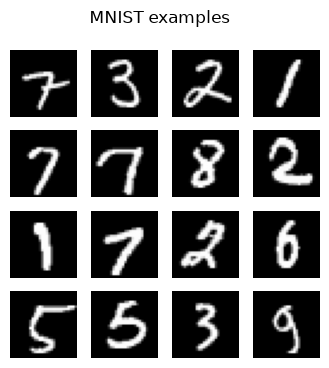

In [3]:
def show_images(x, title=None, n=16):
    x = x.detach().cpu()
    x = x[:n]
    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i].view(28, 28), cmap="gray")
        ax.axis("off")
    if title is not None:
        plt.suptitle(title)
    plt.show()


x_batch, _ = next(iter(train_loader))
show_images(x_batch, title="MNIST examples")

# Part 1: Autoregressive Bernoulli Model

The autoregressive factorization is:

$$p(x)=\prod_{i=1}^{D}p(x_i\mid x_1,\ldots,x_{i-1})$$

Each pixel is modeled as a Bernoulli random variable.

## Task 1.1: Binarize MNIST

In [4]:
def binarize(x):
    return (x > 0.5).float()

## Task 1.2: Implement a Masked Linear Layer

A masked linear layer prevents the model from seeing future pixels.

In [5]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features, mask):
        super().__init__(in_features, out_features)
        self.register_buffer("mask", mask)

    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)

## Task 1.3: Create Autoregressive Masks

For a simple MADE-style model, output dimension \(i\) may depend only on input pixels \(< i\).

In [6]:
def create_ar_mask(input_dim, hidden_dim):
    input_order = torch.arange(input_dim)
    hidden_order = torch.randint(low=0, high=input_dim - 1, size=(hidden_dim,))

    mask1 = (hidden_order[:, None] >= input_order[None, :]).float()
    mask2 = (input_order[:, None] > hidden_order[None, :]).float()

    return mask1, mask2

## Task 1.4: Implement the Autoregressive Model

In [7]:
class AutoregressiveBernoulliModel(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512):
        super().__init__()

        mask1, mask2 = create_ar_mask(input_dim, hidden_dim)

        self.net = nn.Sequential(
            MaskedLinear(input_dim, hidden_dim, mask1),
            nn.ReLU(),
            MaskedLinear(hidden_dim, input_dim, mask2)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        logits = self.net(x)
        return logits

    def log_prob(self, x):
        x = x.view(x.size(0), -1)
        logits = self.forward(x)
        log_prob = -F.binary_cross_entropy_with_logits(
            logits, x, reduction="none"
        )
        return log_prob.sum(dim=1)

    def sample(self, num_samples):
        x = torch.zeros(num_samples, 784).to(device)

        for i in range(784):
            logits = self.forward(x)
            probs = torch.sigmoid(logits[:, i])
            x[:, i] = torch.bernoulli(probs)

        return x.view(num_samples, 1, 28, 28)

## Task 1.5: Train the Autoregressive Model

In [8]:
ar_model = AutoregressiveBernoulliModel().to(device)
optimizer = torch.optim.Adam(ar_model.parameters(), lr=1e-3)

num_epochs = 10
ar_train_nll = []

for epoch in range(num_epochs):
    ar_model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = binarize(x).to(device)

        loss = -ar_model.log_prob(x).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    ar_train_nll.append(avg_loss)
    print(f"Epoch {epoch+1}, Negative Log-Likelihood (NLL): {avg_loss:.4f}")

Epoch 1, Negative Log-Likelihood (NLL): 211.0128
Epoch 2, Negative Log-Likelihood (NLL): 124.4182
Epoch 3, Negative Log-Likelihood (NLL): 107.0466
Epoch 4, Negative Log-Likelihood (NLL): 99.2338
Epoch 5, Negative Log-Likelihood (NLL): 94.7228
Epoch 6, Negative Log-Likelihood (NLL): 91.7689
Epoch 7, Negative Log-Likelihood (NLL): 89.7150
Epoch 8, Negative Log-Likelihood (NLL): 88.1884
Epoch 9, Negative Log-Likelihood (NLL): 87.0125
Epoch 10, Negative Log-Likelihood (NLL): 86.0632


## Task 1.6: Evaluate Test NLL

In [9]:
def evaluate_ar(model, data_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, _ in data_loader:
            x = binarize(x).to(device)
            loss = -model.log_prob(x).mean()
            total_loss += loss.item()
    return total_loss / len(data_loader)


ar_test_nll = evaluate_ar(ar_model, test_loader)
print("Autoregressive Test NLL:", ar_test_nll)

Autoregressive Test NLL: 85.8906944371477


## Task 1.7: Generate Samples

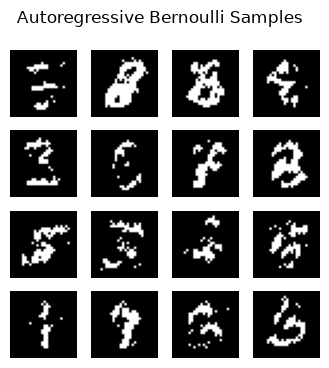

In [10]:
ar_model.eval()
with torch.no_grad():
    samples = ar_model.sample(16)

show_images(samples, title="Autoregressive Bernoulli Samples")

## Questions: Autoregressive Model

Answer in your report:

1. Why is sampling from this model sequential?
2. Why is likelihood evaluation easy?
3. What is the role of the ordering of pixels?
4. Explain why autoregressive models are powerful but slow at generation time.

## Answers: Autoregressive Model

### 1. Why is sampling from this model sequential?

The model writes the probability of an image as a product of conditional probabilities:

$$p(x) = \prod_{i=1}^{D} p(x_i \mid x_1, \dots, x_{i-1})$$

Each pixel is generated using the pixels that came before it. Before sampling $x_i$, the model must already know $x_1,\ldots,x_{i-1}$. It first samples $x_1$, then $x_2$ using $x_1$, and continues in this order.

The masked layers prevent a pixel from using future pixels. For MNIST, this means generating 784 pixels one after another, so the whole image cannot be generated at once.

### 2. Why is likelihood evaluation easy?

When evaluating an existing image, all its pixel values are already known. The masked network can therefore predict the conditional probability of every pixel in one forward pass, while still preventing each prediction from using future pixels.

The image log-likelihood is:

$$\log p(x) = \sum_{i=1}^{D} \log p(x_i \mid x_1, \dots, x_{i-1})$$

For binary pixels, each value is evaluated with a Bernoulli probability. The model adds the log-probabilities of all pixels to get the log-likelihood of the image. This is easier than generation because no new pixels need to be sampled one at a time.

### 3. What is the role of the ordering of pixels?

The ordering decides which pixels are considered earlier and can be used when predicting the current pixel. This model uses raster order: left to right and then top to bottom.

Other fixed orderings are also possible. Changing the order changes the information available for each prediction and may make some pixel relationships easier or harder to learn. The same ordering must also be followed when generating a new image.

### 4. Explain why autoregressive models are powerful but slow at generation time.

Autoregressive models are powerful because each pixel can use information from all earlier pixels. This helps the model learn detailed connections between different parts of an image. The model also gives an exact likelihood that can be evaluated directly.

Generation is slow because the pixels must be sampled one after another. A pixel cannot be generated before the earlier pixels are ready. In this implementation, generating one MNIST image requires 784 prediction steps, while training and likelihood evaluation can process all pixels in one forward pass.

# Part 2: Variational Autoencoder

## Task 2.1: Implement the Encoder

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

## Task 2.2: Implement the Decoder

In [12]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super().__init__()

        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))
        logits = self.fc_out(h)
        return logits

## Task 2.3: Implement the VAE

In [13]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z)
        return logits, mu, logvar

    def sample(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim).to(device)
        logits = self.decoder(z)
        probs = torch.sigmoid(logits)
        return probs.view(num_samples, 1, 28, 28)

## Task 2.4: Implement the ELBO Loss

Use a Bernoulli decoder.

In [14]:
def vae_loss(logits, x, mu, logvar):
    x = x.view(x.size(0), -1)

    reconstruction_loss = F.binary_cross_entropy_with_logits(
        logits, x, reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    loss = reconstruction_loss + kl_divergence

    return loss, reconstruction_loss, kl_divergence

## Task 2.5: Train the VAE

In [15]:
vae = VAE(latent_dim=20).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

num_epochs = 10
vae_loss_curve = []
vae_recon_curve = []
vae_kl_curve = []

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        logits, mu, logvar = vae(x)
        loss, recon_loss, kl = vae_loss(logits, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl.item()

    n = len(train_loader.dataset)
    vae_loss_curve.append(total_loss / n)
    vae_recon_curve.append(total_recon / n)
    vae_kl_curve.append(total_kl / n)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss/n:.4f}, "
        f"Recon: {total_recon/n:.4f}, "
        f"KL: {total_kl/n:.4f}"
    )

Epoch 1, Loss: 165.1155, Recon: 149.9876, KL: 15.1280
Epoch 2, Loss: 121.4830, Recon: 99.4564, KL: 22.0267
Epoch 3, Loss: 114.4843, Recon: 90.9785, KL: 23.5059
Epoch 4, Loss: 111.5772, Recon: 87.5209, KL: 24.0562
Epoch 5, Loss: 109.8447, Recon: 85.4997, KL: 24.3451
Epoch 6, Loss: 108.6516, Recon: 84.0996, KL: 24.5520
Epoch 7, Loss: 107.8221, Recon: 83.0763, KL: 24.7458
Epoch 8, Loss: 107.1203, Recon: 82.2574, KL: 24.8629
Epoch 9, Loss: 106.6373, Recon: 81.6559, KL: 24.9814
Epoch 10, Loss: 106.1274, Recon: 81.1128, KL: 25.0146


## Task 2.6: Generate Samples

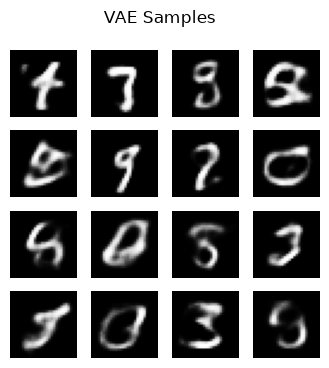

In [16]:
vae.eval()
with torch.no_grad():
    samples = vae.sample(16)

show_images(samples, title="VAE Samples")

## Task 2.7: Latent Space Interpolation

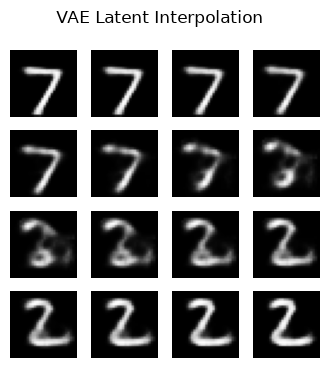

In [17]:
vae.eval()

x_batch, y_batch = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    mu, logvar = vae.encoder(x_batch)
    z = mu

z1 = z[0]
z2 = z[1]

alphas = torch.linspace(0, 1, steps=16).to(device)
z_interp = torch.stack([(1 - a) * z1 + a * z2 for a in alphas])

with torch.no_grad():
    logits = vae.decoder(z_interp)
    imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)

show_images(imgs, title="VAE Latent Interpolation")

## Questions: VAE

Answer in your report:

1. Why do we need the reparameterization trick?
2. What does the KL term encourage?
3. What happens if the KL term becomes almost zero?
4. Why is the VAE likelihood not directly tractable, unlike the autoregressive model?
5. Compare VAE samples with autoregressive samples.

## Answers: VAE

### 1. Why do we need the reparameterization trick?

The encoder produces $\mu$ and $\sigma$. We need to sample $z$ during training, but a direct random sample does not give a useful gradient path from $z$ back to these encoder outputs.

The reparameterization trick rewrites the sampling operation as:

$$z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0,I)$$

The random part is now in $\epsilon$, while $z$ is calculated from the encoder outputs using operations that support backpropagation. This lets the reconstruction loss update the encoder. The sampling is still random; it is only written in a form that allows training.

### 2. What does the KL term encourage?

The KL term encourages the encoder's distribution for each input to stay close to the standard normal prior. This keeps the latent codes from spreading into arbitrary, disconnected regions and makes samples from the prior more useful to the decoder.

It acts as a regularizer. It does not directly guarantee that similar inputs will be close together. The final structure also depends on the reconstruction loss, the model, and the training data.

### 3. What happens if the KL term becomes almost zero?

If the KL term is almost zero for most inputs, the encoder distributions are very close to the prior and may depend very little on the input. Then $z$ can carry little information about the image.

If the decoder also ignores $z$, this is posterior collapse. Reconstructions may become worse and the latent representation becomes less useful. A small KL value is a warning sign, but it is not enough by itself to prove posterior collapse.

### 4. Why is the VAE likelihood not directly tractable, unlike the autoregressive model?

For a VAE, the likelihood of an observed image is obtained by marginalizing over all possible latent variables:

$$p(x) = \int p(x|z)p(z)\,dz$$

The decoder is a nonlinear neural network, so this integral usually has no closed-form solution. The VAE therefore trains with the ELBO, which is a lower bound on the log-likelihood.

An autoregressive model does not need this latent-variable integral. For a complete image, it can directly evaluate the conditional probability of every observed pixel.

### 5. Compare VAE samples with autoregressive samples.

The autoregressive samples are sharper because each pixel is sampled as a binary value. They are easier to recognize, but some contain isolated white pixels, missing parts, or malformed shapes.

The VAE samples are smoother and blurrier. In this notebook, the decoder returns a probability for each pixel and these probabilities are displayed directly, so many pixels are gray instead of black or white. The compressed latent representation, the KL regularization, and the simple decoder can also remove fine details.

Sampling binary pixels from the VAE probabilities would make the images look sharper, but it could add noise and would not necessarily improve the digit shapes. The shown interpolation changes gradually from 7 to 2, but some middle images are unclear. This shows that the latent path is continuous, not that every point produces a clean digit.

# Part 3: Normalizing Flow

For this part, use a **2D toy dataset**, because flows are easier to visualize in low dimensions.

## Task 3.1: Create a 2D Dataset

In [18]:
from sklearn.datasets import make_moons

def make_2d_data(n_samples=10000, seed=42):
    x, _ = make_moons(n_samples=n_samples, noise=0.08, random_state=seed)
    x = x.astype("float32")
    return torch.tensor(x)

data_2d = make_2d_data(seed=42)

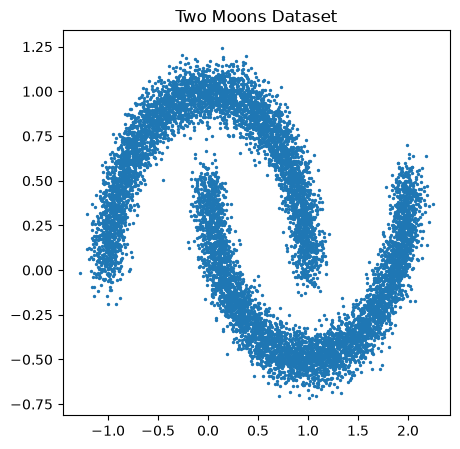

In [19]:
plt.figure(figsize=(5, 5))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=2)
plt.title("Two Moons Dataset")
plt.show()

## Task 3.2: Define a Small Network for Coupling Layers

In [20]:
class CouplingNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

## Task 3.3: Implement an Affine Coupling Layer

For a 2D vector \(x=(x_1,x_2)\), keep one coordinate fixed and transform the other.

In [21]:
class AffineCoupling(nn.Module):
    def __init__(self, flip=False):
        super().__init__()
        self.flip = flip
        self.nn = CouplingNN(input_dim=1, output_dim=2)

    def forward(self, x):
        if self.flip:
            x = torch.flip(x, dims=[1])

        x1 = x[:, :1]
        x2 = x[:, 1:]

        st = self.nn(x1)
        s, t = st[:, :1], st[:, 1:]
        s = torch.tanh(s)

        y1 = x1
        y2 = x2 * torch.exp(s) + t

        y = torch.cat([y1, y2], dim=1)

        if self.flip:
            y = torch.flip(y, dims=[1])

        log_det = s.squeeze(1)

        return y, log_det

    def inverse(self, y):
        if self.flip:
            y = torch.flip(y, dims=[1])

        y1 = y[:, :1]
        y2 = y[:, 1:]

        st = self.nn(y1)
        s, t = st[:, :1], st[:, 1:]
        s = torch.tanh(s)

        x1 = y1
        x2 = (y2 - t) * torch.exp(-s)

        x = torch.cat([x1, x2], dim=1)

        if self.flip:
            x = torch.flip(x, dims=[1])

        log_det = -s.squeeze(1)

        return x, log_det

## Task 3.4: Implement the Full Flow

In [22]:
class RealNVP2D(nn.Module):
    def __init__(self, num_layers=6):
        super().__init__()

        self.layers = nn.ModuleList([
            AffineCoupling(flip=(i % 2 == 1))
            for i in range(num_layers)
        ])

    def base_log_prob(self, z):
        return -0.5 * (z.pow(2).sum(dim=1) + 2 * np.log(2 * np.pi))

    def sample_base(self, num_samples):
        return torch.randn(num_samples, 2).to(device)

    def forward(self, z):
        log_det_total = torch.zeros(z.size(0)).to(device)

        x = z
        for layer in self.layers:
            x, log_det = layer.forward(x)
            log_det_total += log_det

        return x, log_det_total

    def inverse(self, x):
        log_det_total = torch.zeros(x.size(0)).to(device)

        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total += log_det

        return z, log_det_total

    def log_prob(self, x):
        z, log_det = self.inverse(x)
        return self.base_log_prob(z) + log_det

    def sample(self, num_samples):
        z = self.sample_base(num_samples)
        x, _ = self.forward(z)
        return x

## Task 3.5: Train the Flow by Maximum Likelihood

In [23]:
flow = RealNVP2D(num_layers=6).to(device)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)

data_2d = data_2d.to(device)
dataset_2d = torch.utils.data.TensorDataset(data_2d)
loader_2d = DataLoader(dataset_2d, batch_size=256, shuffle=True)

num_epochs = 100
flow_nll_curve = []

for epoch in range(num_epochs):
    flow.train()
    total_loss = 0

    for batch in loader_2d:
        x = batch[0]

        loss = -flow.log_prob(x).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader_2d)
    flow_nll_curve.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, NLL: {avg_loss:.4f}")

Epoch 10, NLL: 1.0148
Epoch 20, NLL: 0.9372
Epoch 30, NLL: 0.8941
Epoch 40, NLL: 0.8464
Epoch 50, NLL: 0.8083
Epoch 60, NLL: 0.8125
Epoch 70, NLL: 0.8369
Epoch 80, NLL: 0.8033
Epoch 90, NLL: 0.8118
Epoch 100, NLL: 0.8046


## Task 3.6: Sample from the Flow

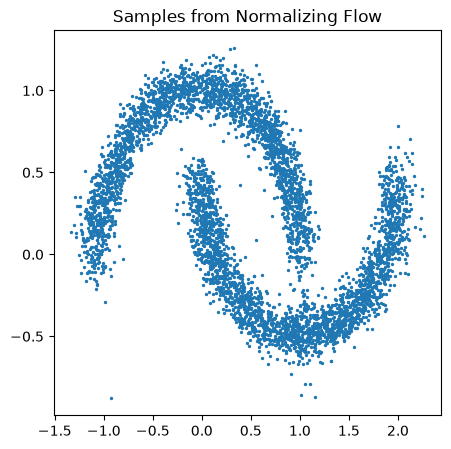

In [24]:
flow.eval()
with torch.no_grad():
    samples = flow.sample(5000).cpu()

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=2)
plt.title("Samples from Normalizing Flow")
plt.show()

## Task 3.7: Visualize Learned Density

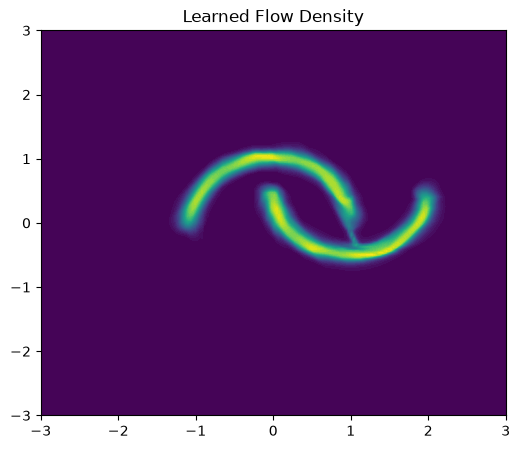

In [25]:
def plot_flow_density(flow, lim=3, n=200):
    x = torch.linspace(-lim, lim, n)
    y = torch.linspace(-lim, lim, n)

    xx, yy = torch.meshgrid(x, y, indexing="ij")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

    with torch.no_grad():
        log_prob = flow.log_prob(grid)
        prob = torch.exp(log_prob).cpu().reshape(n, n)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx.numpy(), yy.numpy(), prob.numpy(), levels=50)
    plt.title("Learned Flow Density")
    plt.show()

plot_flow_density(flow)

## Questions: Normalizing Flows

Answer in your report:

1. Why must the transformation in a normalizing flow be invertible?
2. Why do \(x\) and \(z\) need to have the same dimension?
3. What is the role of the Jacobian determinant?
4. Why are triangular or coupling-layer Jacobians computationally useful?

## Answers: Normalizing Flows

### 1. Why must the transformation be invertible?

The model must work in both directions:

$$x \rightarrow z$$

during likelihood evaluation, and

$$z \rightarrow x$$

during generation. If two different samples $x_1$ and $x_2$ map to the same $z$, information is lost and the inverse is ambiguous. Therefore, the transformation must be one-to-one and invertible.

### 2. Why do $x$ and $z$ need to have the same dimension?

They need the same dimension so the transformation can be invertible. For example, mapping a two-dimensional $x$ to a one-dimensional $z$ would lose information, so $x$ could not be recovered uniquely. Equal dimensions also make the Jacobian square, which is required for its determinant:

$$J_f(x)=\frac{\partial f(x)}{\partial x}$$

### 3. What is the role of the Jacobian determinant?

The Jacobian determinant measures how much the transformation stretches or compresses local area or volume. It corrects the probability density using the change-of-variables formula. For $z=f(x)$:

$$p_X(x)=p_Z(f(x))\left|\det\left(\frac{\partial f(x)}{\partial x}\right)\right|$$

For example, consider:

$$z_1=2x_1,\qquad z_2=3x_2$$

Its Jacobian and determinant are:

$$J_f=\begin{bmatrix}2&0\\0&3\end{bmatrix},\qquad |\det J_f|=6$$

The transformation stretches area by a factor of $6$, so the density is corrected by the same factor in the $x\rightarrow z$ formula:

$$p_X(x)=6\,p_Z(f(x))$$

For several flow layers, the log-determinants are added:

$$\log p_X(x)=\log p_Z(z)+\sum_k\log|\det J_{f_k}|$$

### 4. Why are triangular or coupling-layer Jacobians computationally useful?

For a triangular Jacobian, the determinant is the product of its diagonal entries:

$$\det(J)=\prod_i J_{ii}$$

This takes $O(d)$ time instead of about $O(d^3)$ for a general matrix. An affine coupling layer splits the input as:

$$x=(x_a,x_b)$$

and applies:

$$y_a=x_a$$

$$y_b=x_b\odot\exp(s(x_a))+t(x_a)$$

Its Jacobian is triangular, giving:

$$\log|\det J|=\sum_i s_i(x_a)$$

Therefore, coupling layers provide an easy inverse and a cheap, exact Jacobian determinant.

# Part 5: Required Experiments

Implement and run the following experiments and report the results.

In [26]:
EXPERIMENT_SEED = 42

def set_experiment_seed(seed=EXPERIMENT_SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_seeded_loader(dataset, batch_size, shuffle, seed=EXPERIMENT_SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)

## Experiment 1: Autoregressive Hidden Size

Train autoregressive models with:

```python
hidden_dims = [128, 512, 1024]
```

Report:

1. Train NLL.
2. Test NLL.
3. Sample quality.

hidden_dim=128: train=112.6488, validation=113.4508, test=111.9399


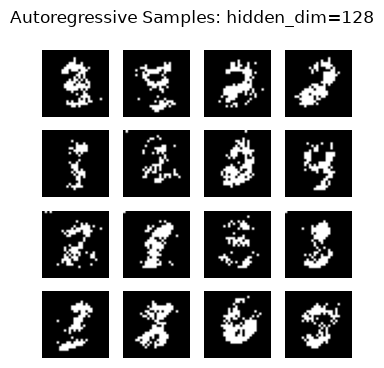

hidden_dim=512: train=86.2253, validation=88.1389, test=86.7588


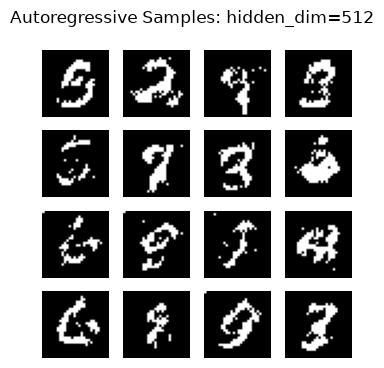

hidden_dim=1024: train=75.7864, validation=78.6336, test=77.4442


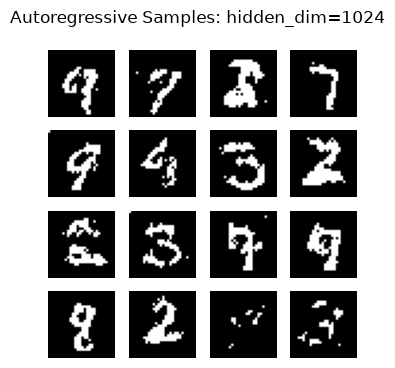

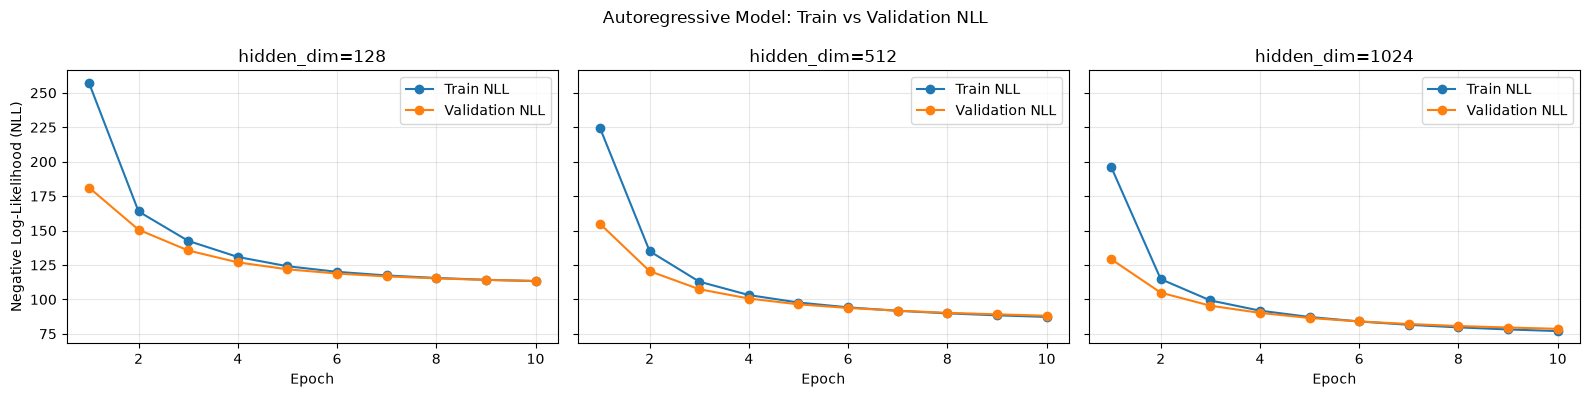

In [27]:
validation_size = 10_000
training_size = len(train_dataset) - validation_size
split_generator = torch.Generator().manual_seed(EXPERIMENT_SEED)
ar_train_dataset, ar_val_dataset = torch.utils.data.random_split(
    train_dataset,
    [training_size, validation_size],
    generator=split_generator,
)
ar_val_loader = make_seeded_loader(ar_val_dataset, batch_size, False)

def train_ar_experiment(hidden_dim, epochs=10):
    set_experiment_seed()
    loader = make_seeded_loader(ar_train_dataset, batch_size, True)
    model = AutoregressiveBernoulliModel(hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_nll_history = []
    val_nll_history = []

    for epoch in range(epochs):
        model.train()
        total_nll = 0.0
        for x, _ in loader:
            x = binarize(x).to(device)
            loss = -model.log_prob(x).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_nll += loss.item() * len(x)

        train_nll = total_nll / len(ar_train_dataset)
        train_nll_history.append(train_nll)
        val_nll = evaluate_ar(model, ar_val_loader)
        val_nll_history.append(val_nll)

    return model, train_nll_history, val_nll_history

hidden_dims = [128, 512, 1024]
ar_experiment_results = {}

for hidden_dim in hidden_dims:
    model, train_history, val_history = train_ar_experiment(hidden_dim)
    model.eval()
    with torch.no_grad():
        samples = model.sample(16).cpu()

    ar_experiment_results[hidden_dim] = {
        "train_history": train_history,
        "validation_history": val_history,
        "train_nll": evaluate_ar(model, make_seeded_loader(ar_train_dataset, batch_size, False)),
        "validation_nll": evaluate_ar(model, ar_val_loader),
        "test_nll": evaluate_ar(model, test_loader),
        "samples": samples,
    }
    result = ar_experiment_results[hidden_dim]
    print(f"hidden_dim={hidden_dim}: train={result['train_nll']:.4f}, validation={result['validation_nll']:.4f}, test={result['test_nll']:.4f}")
    show_images(samples, title=f"Autoregressive Samples: hidden_dim={hidden_dim}")

fig, axes = plt.subplots(1, len(hidden_dims), figsize=(16, 4), sharey=True)
for ax, hidden_dim in zip(axes, hidden_dims):
    result = ar_experiment_results[hidden_dim]
    epochs = range(1, len(result["train_history"]) + 1)
    ax.plot(epochs, result["train_history"], marker="o", label="Train NLL")
    ax.plot(epochs, result["validation_history"], marker="o", label="Validation NLL")
    ax.set_title(f"hidden_dim={hidden_dim}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Negative Log-Likelihood (NLL)")
fig.suptitle("Autoregressive Model: Train vs Validation NLL")
plt.tight_layout()
plt.show()

### Autoregressive Hidden-Size Results

| Hidden dimension | Train NLL | Validation NLL | Test NLL | Sample quality |
|---:|---:|---:|---:|---|
| 128 | 112.6488 | 113.4508 | 111.9399 | Mostly recognizable, but noisy and often malformed |
| 512 | 86.2253 | 88.1389 | 86.7588 | Clearer shapes and more recognizable digits, with some noise |
| 1024 | **75.7864** | **78.6336** | **77.4442** | Best overall, sharper and more recognizable, though some samples remain incomplete |

Increasing the hidden dimension improves both NLL and sample quality. The 1024-unit model gives the best result. Its training and validation curves remain close, although the small gap near the end suggests mild overfitting.

## Experiment 2: VAE Latent Dimension

Train VAEs with:

```python
latent_dims = [2, 10, 20, 50]
```

Report:

1. Reconstruction loss.
2. KL divergence.
3. Sample quality.
4. Latent interpolation results.

latent_dim=2: recon=149.5053, KL=5.7619


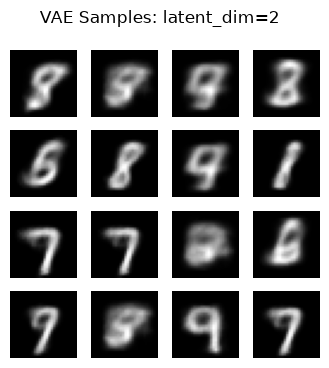

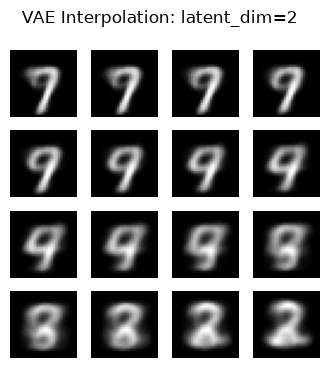

latent_dim=10: recon=92.7980, KL=17.8758


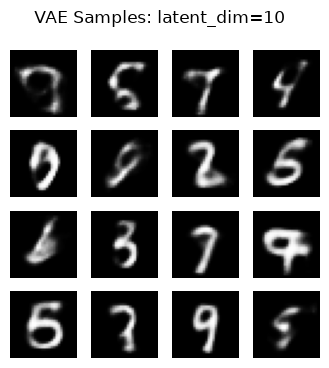

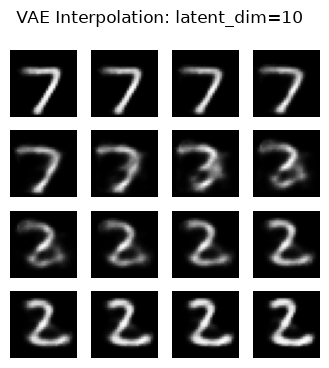

latent_dim=20: recon=80.7947, KL=24.9559


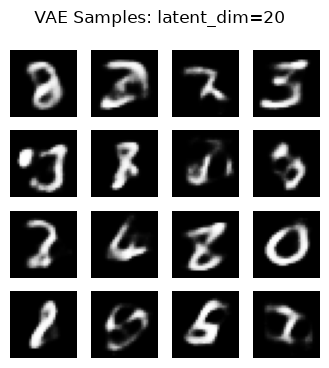

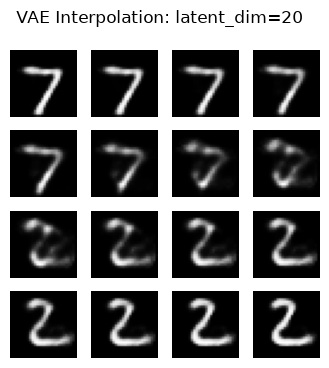

latent_dim=50: recon=79.9824, KL=26.1470


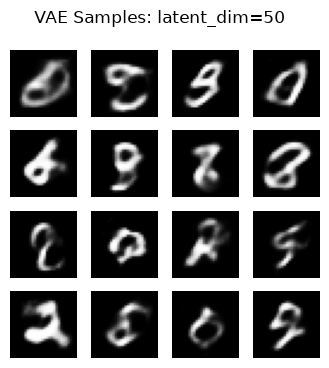

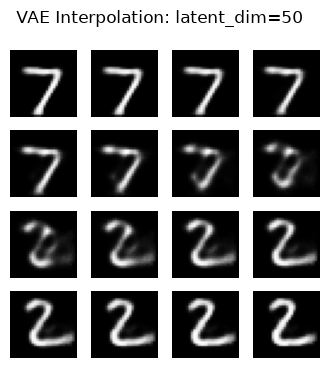

In [28]:
def evaluate_vae_experiment(model, loader):
    model.eval()
    reconstruction = 0.0
    kl_divergence = 0.0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            logits, mu, logvar = model(x)
            _, recon, kl = vae_loss(logits, x, mu, logvar)
            reconstruction += recon.item()
            kl_divergence += kl.item()
    n = len(loader.dataset)
    return reconstruction / n, kl_divergence / n

def train_vae_experiment(latent_dim, epochs=10):
    set_experiment_seed()
    loader = make_seeded_loader(train_dataset, batch_size, True)
    model = VAE(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(epochs):
        model.train()
        for x, _ in loader:
            x = x.to(device)
            logits, mu, logvar = model(x)
            loss, _, _ = vae_loss(logits, x, mu, logvar)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

latent_dims = [2, 10, 20, 50]
vae_experiment_results = {}
interp_x = next(iter(test_loader))[0][:2].to(device)

for latent_dim in latent_dims:
    model = train_vae_experiment(latent_dim)
    reconstruction, kl_divergence = evaluate_vae_experiment(model, test_loader)
    model.eval()
    with torch.no_grad():
        samples = model.sample(16).cpu()
        mu, _ = model.encoder(interp_x)
        alpha = torch.linspace(0, 1, 16, device=device)[:, None]
        z = (1 - alpha) * mu[0] + alpha * mu[1]
        interpolation = torch.sigmoid(model.decoder(z)).view(-1, 1, 28, 28).cpu()

    vae_experiment_results[latent_dim] = {
        "reconstruction": reconstruction,
        "kl": kl_divergence,
        "samples": samples,
        "interpolation": interpolation,
    }
    print(f"latent_dim={latent_dim}: recon={reconstruction:.4f}, KL={kl_divergence:.4f}")
    show_images(samples, title=f"VAE Samples: latent_dim={latent_dim}")
    show_images(interpolation, title=f"VAE Interpolation: latent_dim={latent_dim}")

### VAE Latent-Dimension Results

| Latent dimension | Test reconstruction loss | Test KL divergence | Sample quality | Interpolation |
|---:|---:|---:|---|---|
| 2 | 149.5053 | 5.7619 | Recognizable but very blurry, with little variety | Smooth but blurry transition from 7 through 9 to 8 |
| 10 | 92.7980 | 17.8758 | Sharper and more varied, but several digits remain unclear | Smooth 7-to-2 transition with unclear middle images |
| 20 | 80.7947 | 24.9559 | Sharp and varied overall, though some samples are malformed | Smooth and detailed 7-to-2 transition |
| 50 | 79.9824 | 26.1470 | Similar to 20 dimensions, with no consistent visual improvement | Smooth 7-to-2 transition, similar to 20 dimensions |

Increasing the latent dimension strongly improves reconstruction from 2 to 20 dimensions. Moving from 20 to 50 gives only a small reconstruction improvement, increases the KL divergence, and does not clearly improve samples or interpolation. Therefore, 20 latent dimensions provide the best balance in this experiment.

## Experiment 3: Flow Depth

Train flows with:

```python
num_layers = [2, 4, 8, 12]
```

Report:

1. Negative log-likelihood.
2. Density visualization.
3. Sample quality.
4. Whether deeper flows improve the learned distribution.

layers=2: train NLL=1.5264, validation NLL=1.5288
layers=4: train NLL=0.9972, validation NLL=1.0166
layers=8: train NLL=0.8103, validation NLL=0.8074
layers=12: train NLL=0.8209, validation NLL=0.8197


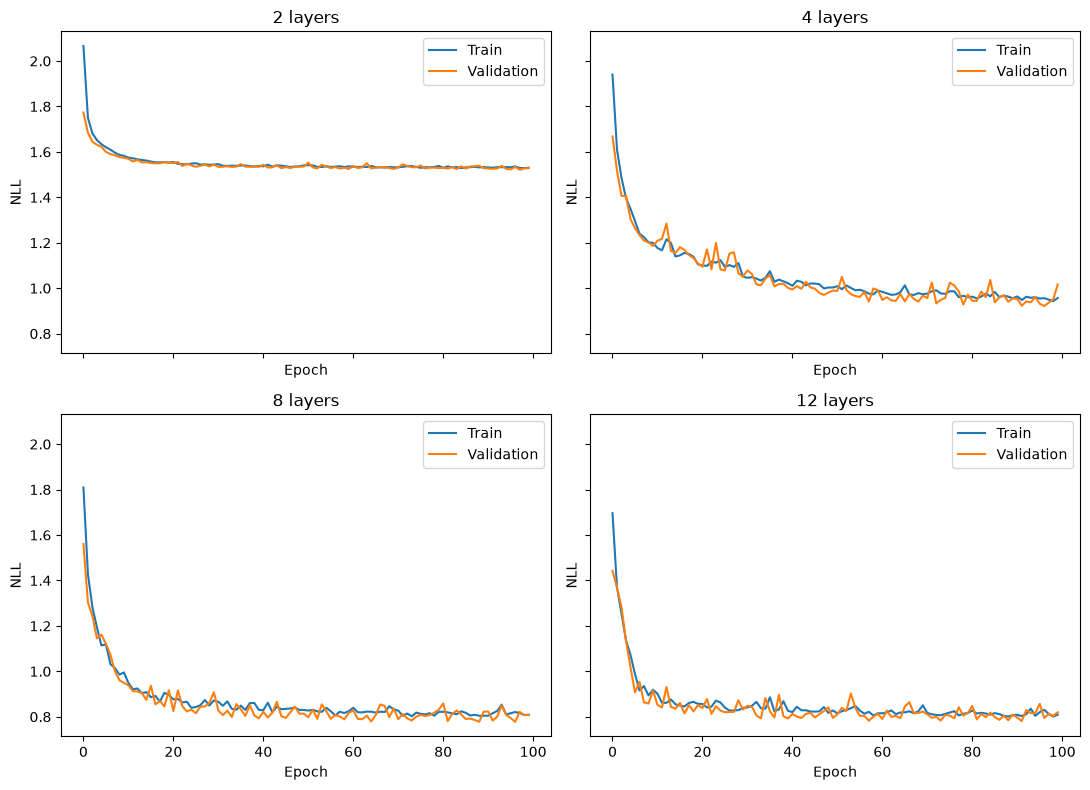

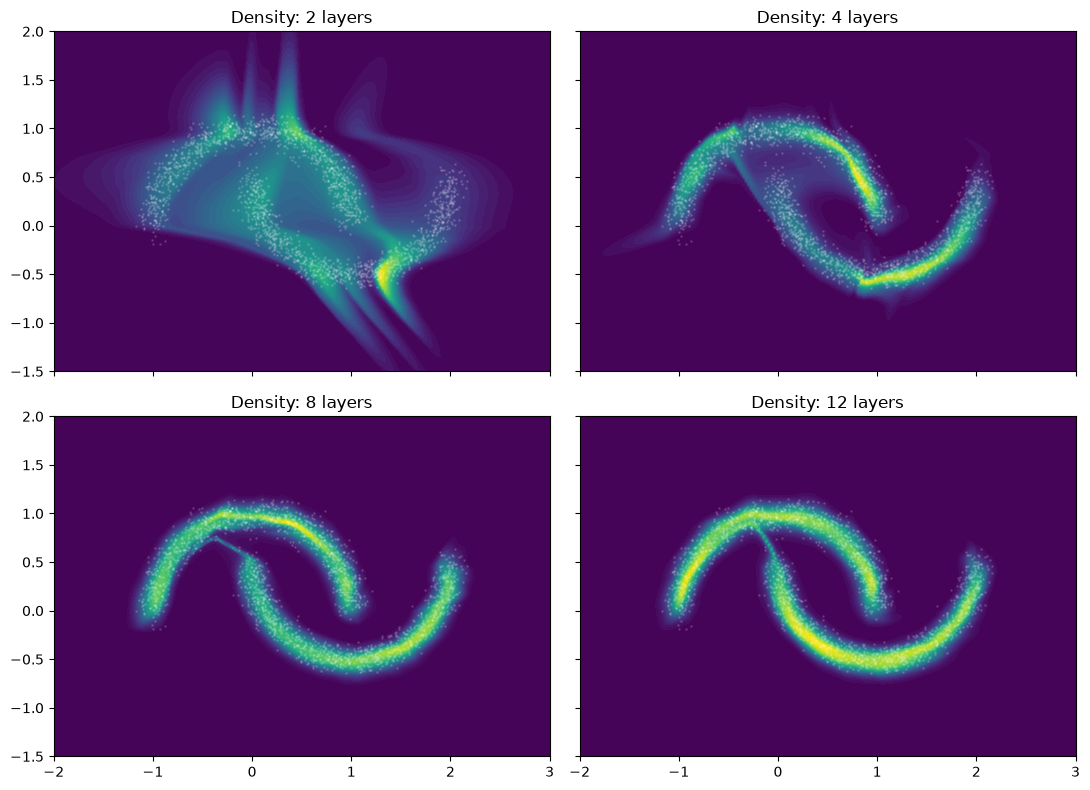

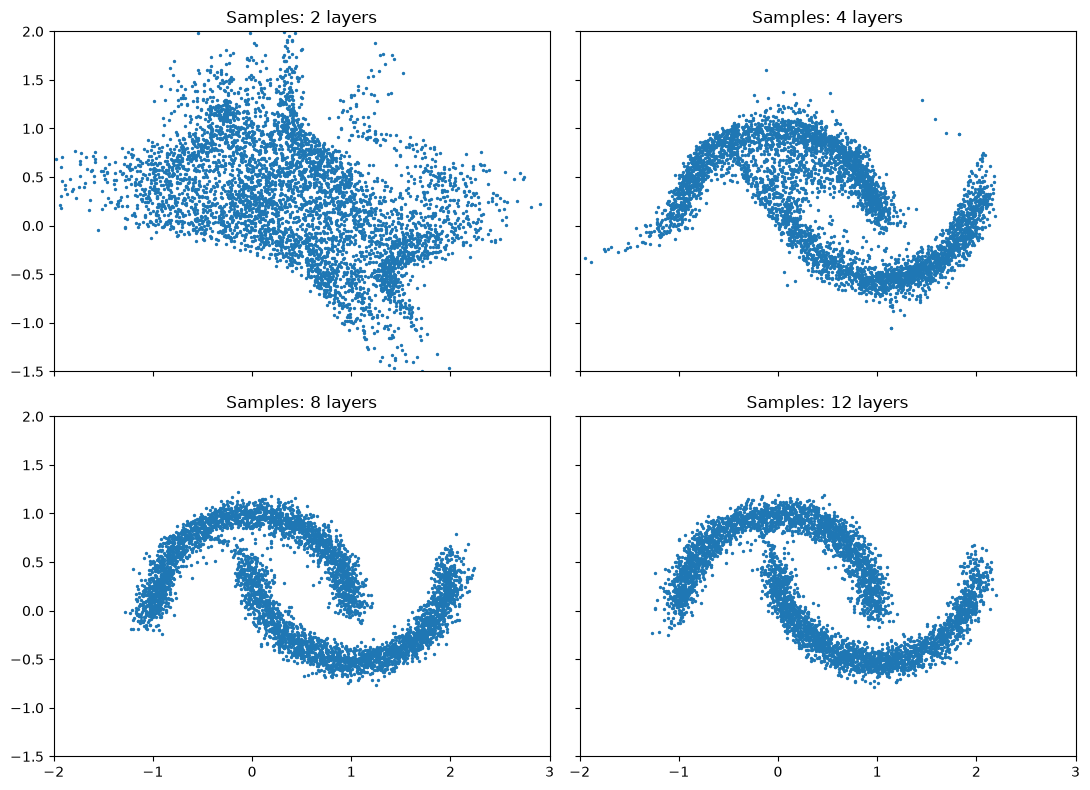

In [29]:
def evaluate_flow_experiment(model, data):
    model.eval()
    with torch.no_grad():
        return -model.log_prob(data.to(device)).mean().item()

def train_flow_experiment(depth, train_data, val_data, epochs=100):
    set_experiment_seed()
    loader = make_seeded_loader(
        torch.utils.data.TensorDataset(train_data), 256, True
    )
    model = RealNVP2D(num_layers=depth).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_history, val_history = [], []

    for _ in range(epochs):
        model.train()
        train_total = 0.0
        for (x,) in loader:
            x = x.to(device)
            loss = -model.log_prob(x).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_total += loss.item() * len(x)
        train_history.append(train_total / len(train_data))
        val_history.append(evaluate_flow_experiment(model, val_data))

    return model, train_history, val_history

num_layers = [2, 4, 8, 12]
flow_experiment_results = {}
flow_data = make_2d_data(seed=EXPERIMENT_SEED)
generator = torch.Generator().manual_seed(EXPERIMENT_SEED)
indices = torch.randperm(len(flow_data), generator=generator)
split = int(0.8 * len(flow_data))
train_data = flow_data[indices[:split]]
val_data = flow_data[indices[split:]]

for depth in num_layers:
    model, train_history, val_history = train_flow_experiment(
        depth, train_data, val_data
    )
    model.eval()
    with torch.no_grad():
        samples = model.sample(5000).cpu()

    flow_experiment_results[depth] = {
        "model": model,
        "train_nll": evaluate_flow_experiment(model, train_data),
        "validation_nll": evaluate_flow_experiment(model, val_data),
        "train_history": train_history,
        "validation_history": val_history,
        "samples": samples,
    }
    result = flow_experiment_results[depth]
    print(f"layers={depth}: train NLL={result['train_nll']:.4f}, validation NLL={result['validation_nll']:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, depth in zip(axes.flat, num_layers):
    result = flow_experiment_results[depth]
    ax.plot(result["train_history"], label="Train")
    ax.plot(result["validation_history"], label="Validation")
    ax.set_title(f"{depth} layers")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL")
    ax.legend()
plt.tight_layout()
plt.show()

x_grid = torch.linspace(-2, 3, 200)
y_grid = torch.linspace(-1.5, 2, 200)
xx, yy = torch.meshgrid(x_grid, y_grid, indexing="ij")
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, depth in zip(axes.flat, num_layers):
    model = flow_experiment_results[depth]["model"]
    with torch.no_grad():
        density = model.log_prob(grid).exp().cpu().reshape(200, 200)
    ax.contourf(xx.numpy(), yy.numpy(), density.numpy(), levels=50)
    ax.scatter(val_data[:, 0], val_data[:, 1], s=1, c="white", alpha=0.12)
    ax.set_title(f"Density: {depth} layers")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, depth in zip(axes.flat, num_layers):
    samples = flow_experiment_results[depth]["samples"]
    ax.scatter(samples[:, 0], samples[:, 1], s=2)
    ax.set_xlim(-2, 3)
    ax.set_ylim(-1.5, 2)
    ax.set_title(f"Samples: {depth} layers")
plt.tight_layout()
plt.show()

### Flow-Depth Results

| Number of layers | Train NLL | Validation NLL | Density visualization | Sample quality |
|---:|---:|---:|---|---|
| 2 | 1.5264 | 1.5288 | Does not separate the two moons; density is spread through the middle | Poor; samples form a wide, unstructured cloud |
| 4 | 0.9972 | 1.0166 | Learns both moon shapes, but the density is uneven and has thin tails | Good basic structure, with noticeable noise and outliers |
| 8 | **0.8103** | **0.8074** | Closely follows both moons with smooth, concentrated density | Best overall, clean moon shapes with relatively few outliers |
| 12 | 0.8209 | 0.8197 | Closely follows both moons, but is not better than 8 layers | Very good and similar to 8 layers, with no clear improvement |

Increasing the depth from 2 to 4 and then to 8 layers clearly improves the learned distribution. The validation NLL decreases, and the density and samples match the two-moons shape more closely. Increasing the depth from 8 to 12 layers does not improve the result: validation NLL becomes slightly worse, from 0.8074 to 0.8197, while the density and samples look similar. This shows diminishing returns rather than a benefit from extra depth. For this experiment, 8 layers give the best result.